# FarmTech Solutions — o começo da rede neural
**Matheus Silva Riscado · RM573622 · individual · entrega em 13/10/2026**

**Verificação concluída em 06/10/2026.** Esta cópia registra a execução integral em sessão T4 nova, com contadores 1–15 e nenhuma saída de erro. Execução: `20261006T122041599048Z`. Dados baixados do GitHub público, sem montar o Drive durante os experimentos.

Os resultados e a discussão abaixo pertencem a esta segunda rodada. A versão principal de entrega preserva o experimento de 04/10/2026. A seção 9 documenta as diferenças; nenhuma rodada foi escolhida por ter resultados melhores no teste.

**Objetivo:** demonstrar detecção de objetos com YOLOv5 customizado em 30 e 60 épocas,
comparar com YOLOv3 padrão e treinar uma CNN de classificação do zero.
Classes escolhidas: `garrafa` (0) e `banana` (1).

### Procedência da coleta — 03/10/2026
- Garrafas: 14 fotografias do autor e 26 do Wikimedia Commons; bananas: 40 do Wikimedia Commons.
- Cada classe: 32 imagens de treino, 4 de validação e 4 de teste. As fotografias da sessão doméstica ficam no treino; autores do Commons foram agrupados para não atravessar conjuntos.
- O manifesto `dataset/fontes.csv` registra arquivo, split, grupo, origem, autoria, licença e hashes. Manter os créditos de `coleta/garrafas/CREDITOS.md` e `coleta/bananas/CREDITOS.md` com a distribuição dos dados.
- Três fotos adicionais com banana e garrafas juntas ficam fora das métricas e da CNN; compartilham a sessão de treino e servem apenas para demonstração qualitativa.
- A coleta foi revisada visualmente e não contém duplicatas exatas. As caixas foram feitas no Make Sense AI com sugestões YOLOv5m/COCO revisadas e complementação manual; isso não equivale ao treino customizado. O ZIP YOLO foi importado e validado em 04/10/2026, e o auditor deste notebook aprovou os dados reais. Uma caixa de `garrafa_011` foi ajustada manualmente após inspeção ampliada para excluir uma colher ao fundo; a exportação original e o ajuste estão preservados em `evidencias/exportacoes` e `docs/AJUSTES-ROTULOS.json`. Fotos públicas podem ter aparecido no pré-treino externo; essa sobreposição não foi auditada.

## 1. Perguntas e método
1. Dobrar o orçamento de 30 para 60 épocas melhora a validação e compensa o tempo adicional?
2. Como YOLOv5, YOLOv3 e CNN se comportam nas mesmas imagens?
3. Quais erros limitam a aplicação no cenário do cliente?

**Hipóteses, não resultados:** o ajuste do YOLO pode ajudar no domínio escolhido; mais épocas
também podem causar sobreajuste; a CNN pode memorizar uma base pequena. Nenhuma vitória é presumida.

### Premissas
- 40 fotos reais por classe, divididas em 32/4/4 para treino/validação/teste.
- Uma única classe-alvo por imagem; todas as suas instâncias são anotadas.
- Unidade de anotação: cada garrafa; cada banana solta ou penca/cacho fisicamente unido. Pencas distintas recebem caixas distintas, sem duplicar caixas por fruto dentro de um cacho. Aplicar a mesma regra aos três splits. Ver `docs/PROTOCOLO-ROTULACAO.md`.
- A convenção de penca/cacho pode divergir das caixas individuais do COCO. Discutir essa diferença ao comparar localização; a comparação por classe da imagem não mede contagem de frutos.
- Divisão fixa por grupos de captura; sem duplicatas entre os conjuntos.
- Aumento de dados somente durante o treino. Validação seleciona o modelo; teste só avalia ao final.
- Mesmos pesos iniciais, seed, tamanho de imagem e batch nos dois experimentos YOLOv5.
- A CNN é classificadora e não prevê caixas. Não comparar sua acurácia diretamente com mAP.
- YOLOv3 possui pré-treino externo em COCO, YOLOv5 usa os mesmos pesos iniciais externos em cada
  experimento, e a CNN não usa pré-treino. Comparação de soluções, não isolamento causal de arquitetura.

### Execução
No Colab, selecionar um runtime com GPU. A disponibilidade e duração da sessão variam.
Preencher a próxima célula, montar o Drive, executar em ordem e acompanhar as mensagens de erro.
O dataset deve estar em `Meu Drive/FarmTechFase6/dataset` conforme o guia `COMECE-AQUI.md`.

In [1]:
from pathlib import Path
import os, sys, json, csv, hashlib, subprocess, shutil, time, platform, gc
from datetime import datetime, timezone

# Classes escolhidas: manter esta ordem também no Make Sense AI.
CLASSES = ["garrafa", "banana"]
COCO_NAMES = ["bottle", "banana"]  # Correspondência na mesma ordem de CLASSES.
SEED, IMAGE_SIZE, BATCH_SIZE = 42, 640, 8
EPOCHS = [30, 60]
CONFIDENCE, NMS_IOU = 0.25, 0.45
USE_DRIVE = False
DRIVE_ROOT = Path("/content/drive/MyDrive/FarmTechFase6")

# Para o avaliador: link direto HTTPS de ZIP autorizado, contendo images/, labels/ e fontes.csv.
# Quando preenchido, ele pode usar USE_DRIVE=False e rodar sem acesso ao Drive do autor.
DATASET_ZIP_URL = "https://github.com/teteuriscado-bot/MatheusSilvaRiscado/releases/download/fase6-2026-10-04/DATASET-FARMTECH-FASE6.zip"
YOLOV5_REVISION = "2b1bdcd03663afe204bb614593f78be3facfbcaa"
WORK = Path("/content/farmtech_fase6")
WORK.mkdir(parents=True, exist_ok=True)
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
print("Classes:", CLASSES, "| Execução:", RUN_ID)


Classes: ['garrafa', 'banana'] | Execução: 20261006T122041599048Z


## 2. Ambiente e preservação dos resultados

Execução de 06/10/2026 com Python 3.13.15, PyTorch 2.11.0+cu130 e GPU Tesla T4. A CNN e a inferência comparativa usam CPU conforme o protocolo. A revisão YOLOv5 permanece fixada em `2b1bdcd03663afe204bb614593f78be3facfbcaa`.

`ambiente.json` e `requirements-executados.txt` registram a sessão. As 15 células foram concluídas sem intervenções durante a execução. Somente depois foi tentado um backup adicional no Drive, que falhou na montagem; o ZIP já baixado pelo Chrome foi preservado e auditado localmente. Isso não integra nem altera o teste das 15 células.

In [2]:
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    OUT = DRIVE_ROOT / "resultados" / RUN_ID
else:
    OUT = WORK / "resultados" / RUN_ID
OUT.mkdir(parents=True, exist_ok=False)

# subprocess com lista de argumentos evita problemas de espaços e expansão de shell.
def run_command(arguments, cwd=None):
    subprocess.run([str(a) for a in arguments], cwd=cwd, check=True)

REPO = WORK / "yolov5"
if not REPO.exists():
    run_command(["git", "clone", "https://github.com/ultralytics/yolov5.git", REPO])
run_command(["git", "checkout", "--detach", YOLOV5_REVISION], cwd=REPO)
run_command([sys.executable, "-m", "pip", "install", "-q", "-r", REPO / "requirements.txt"])
run_command([sys.executable, "-m", "pip", "install", "-q", "tensorflow", "scikit-learn"])
freeze = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True)
(OUT / "requirements-executados.txt").write_text(freeze, encoding="utf-8")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import torch
from PIL import Image, ImageDraw, ImageOps
from IPython.display import display, Markdown
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

DEVICE = "0" if torch.cuda.is_available() else "cpu"
environment = {"python": sys.version, "platform": platform.platform(),
               "torch": torch.__version__, "yolov5_revision": YOLOV5_REVISION,
               "training_device": DEVICE, "run_id": RUN_ID,
               "gpu": torch.cuda.get_device_name(0) if DEVICE == "0" else None}
(OUT / "ambiente.json").write_text(json.dumps(environment, indent=2), encoding="utf-8")
display(environment)
plt.rcParams.update({"figure.figsize": (9, 4), "font.size": 11, "axes.grid": True})
EPOCH_COLORS = {30: "#2563a6", 60: "#c17c1f"}


{'python': '3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]',
 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39',
 'torch': '2.11.0+cu130',
 'yolov5_revision': '2b1bdcd03663afe204bb614593f78be3facfbcaa',
 'training_device': '0',
 'run_id': '20261006T122041599048Z',
 'gpu': 'Tesla T4'}

## 3. Dados e auditoria antes do treinamento
Anotar as imagens no **Make Sense AI** e preservar o ZIP original da exportação.
Usar os mesmos IDs em todos os conjuntos. Também são necessárias caixas de referência na
validação e no teste. O arquivo `fontes.csv` registra `arquivo,split,classe,grupo,origem,licenca_ou_autorizacao`.

Não preencher dados fictícios para superar uma checagem. O código abaixo rejeita imagens corrompidas,
contagens incorretas, rótulos inválidos, grupos que atravessam conjuntos e duplicatas exatas de pixels.
Imagens quase iguais exigem revisão manual. Nenhuma checagem automática garante a qualidade das caixas.


In [3]:
import zipfile
from urllib.request import urlretrieve

DATA = WORK / ("dataset_" + RUN_ID)
if DATASET_ZIP_URL:
    assert DATASET_ZIP_URL.startswith("https://"), "Usar um link direto HTTPS autorizado."
    archive_path = WORK / ("dataset_" + RUN_ID + ".zip")
    urlretrieve(DATASET_ZIP_URL, archive_path)
    DATA.mkdir()
    with zipfile.ZipFile(archive_path) as archive:
        # Impedir caminhos fora do diretório de extração.
        for member in archive.infolist():
            destination = (DATA / member.filename).resolve()
            if not destination.is_relative_to(DATA.resolve()):
                raise ValueError("Caminho inseguro no ZIP: " + member.filename)
        archive.extractall(DATA)
else:
    source = DRIVE_ROOT / "dataset"
    if not USE_DRIVE or not source.exists():
        raise FileNotFoundError("Preencher DATASET_ZIP_URL ou organizar o dataset no Drive.")
    shutil.copytree(source, DATA)

EXPECTED = {"train": 32, "val": 4, "test": 4}
EXTENSIONS = {".jpg", ".jpeg", ".png"}
provenance = pd.read_csv(DATA / "fontes.csv", keep_default_na=False, dtype=str)
required = ["arquivo", "split", "classe", "grupo", "origem", "licenca_ou_autorizacao"]
if any(c not in provenance for c in required):
    raise ValueError("fontes.csv deve conter: " + ", ".join(required))
if provenance.empty or provenance[required].apply(lambda s: s.str.strip().eq("")).any().any():
    raise ValueError("Registrar a procedência de todas as imagens, sem campos vazios.")
if provenance.duplicated(["split", "arquivo"]).any():
    raise ValueError("Há registros repetidos no fontes.csv.")
if (provenance.groupby("grupo")["split"].nunique() > 1).any():
    raise ValueError("Vazamento: um grupo de captura aparece em conjuntos diferentes.")

records, pixel_hashes, used_keys = [], {}, set()
for split, expected_per_class in EXPECTED.items():
    paths = sorted(p for p in (DATA / "images" / split).iterdir() if p.suffix.lower() in EXTENSIONS)
    if len({p.stem for p in paths}) != len(paths):
        raise ValueError("Nomes-base repetidos no conjunto " + split)
    for path in paths:
        label_path = DATA / "labels" / split / (path.stem + ".txt")
        if not label_path.is_file() or not label_path.read_text().strip():
            raise ValueError("Anotação ausente ou vazia: " + str(label_path))
        rows = [list(map(float, line.split())) for line in label_path.read_text().splitlines() if line.strip()]
        if any(len(row) != 5 for row in rows):
            raise ValueError("Esperados cinco campos YOLO: " + str(label_path))
        boxes = np.asarray(rows, dtype=float)
        if not np.isfinite(boxes).all():
            raise ValueError("Anotação com valores não finitos: " + str(label_path))
        ids, xywh = boxes[:, 0], boxes[:, 1:]
        if not np.isin(ids, [0, 1]).all() or len(set(ids)) != 1:
            raise ValueError("Usar apenas uma classe-alvo por imagem, ID 0 ou 1: " + path.name)
        if (xywh < 0).any() or (xywh > 1).any() or (xywh[:, 2:] <= 0).any():
            raise ValueError("Coordenadas YOLO inválidas: " + path.name)
        if ((xywh[:, :2] - xywh[:, 2:] / 2) < -1e-5).any() or ((xywh[:, :2] + xywh[:, 2:] / 2) > 1 + 1e-5).any():
            raise ValueError("Caixa fora da imagem: " + path.name)
        with Image.open(path) as original:
            if original.getexif().get(274, 1) != 1:
                raise ValueError("Normalizar orientação EXIF antes de rotular: " + path.name)
            image = original.convert("RGB")
            pixels = str(image.size).encode() + image.tobytes()
            digest = hashlib.sha256(pixels).hexdigest()
            width, height = image.size
        if digest in pixel_hashes:
            raise ValueError("Imagem duplicada: " + path.name + " / " + pixel_hashes[digest])
        pixel_hashes[digest] = path.name
        match = provenance[(provenance.split == split) & (provenance.arquivo == path.name)]
        if len(match) != 1 or match.iloc[0].classe != CLASSES[int(ids[0])]:
            raise ValueError("Procedência ausente/incompatível com a classe: " + path.name)
        used_keys.add((split, path.name))
        records.append({"path": str(path), "arquivo": path.name, "split": split,
                        "class_id": int(ids[0]), "classe": CLASSES[int(ids[0])],
                        "caixas": len(rows), "largura": width, "altura": height,
                        "sha256_pixels": digest, "grupo": match.iloc[0].grupo})
    counts = pd.Series([r["class_id"] for r in records if r["split"] == split]).value_counts()
    if any(counts.get(i, 0) != expected_per_class for i in [0, 1]):
        raise ValueError(f"{split}: exigidas {expected_per_class} imagens de cada classe.")
    expected_labels = {p.stem + ".txt" for p in paths}
    actual_labels = {p.name for p in (DATA / "labels" / split).glob("*.txt")}
    if actual_labels != expected_labels:
        raise ValueError("Há anotações órfãs ou arquivos extras em labels/" + split)
if used_keys != set(zip(provenance.split, provenance.arquivo)):
    raise ValueError("fontes.csv possui linhas que não correspondem às imagens carregadas.")

manifest = pd.DataFrame(records)
manifest.to_csv(OUT / "manifesto_auditado.csv", index=False)
shutil.copy2(DATA / "fontes.csv", OUT / "fontes.csv")
display(pd.crosstab(manifest.classe, manifest.split).reindex(columns=["train", "val", "test"]))
DATA_YAML = WORK / ("dataset_" + RUN_ID + ".yaml")
DATA_YAML.write_text(yaml.safe_dump({"path": str(DATA), "train": "images/train",
                    "val": "images/val", "test": "images/test", "nc": 2,
                    "names": CLASSES}, allow_unicode=True), encoding="utf-8")
shutil.copy2(DATA_YAML, OUT / "dataset-executado.yaml")
print("Auditoria estrutural aprovada. A revisão visual ainda é necessária.")


split,train,val,test
classe,,,
banana,32,4,4
garrafa,32,4,4


Auditoria estrutural aprovada. A revisão visual ainda é necessária.


### Revisão visual das caixas
Revisar todas as imagens e anotações antes de treinar. A célula mostra apenas exemplos do treino;
não escolher hiperparâmetros observando os resultados do teste.


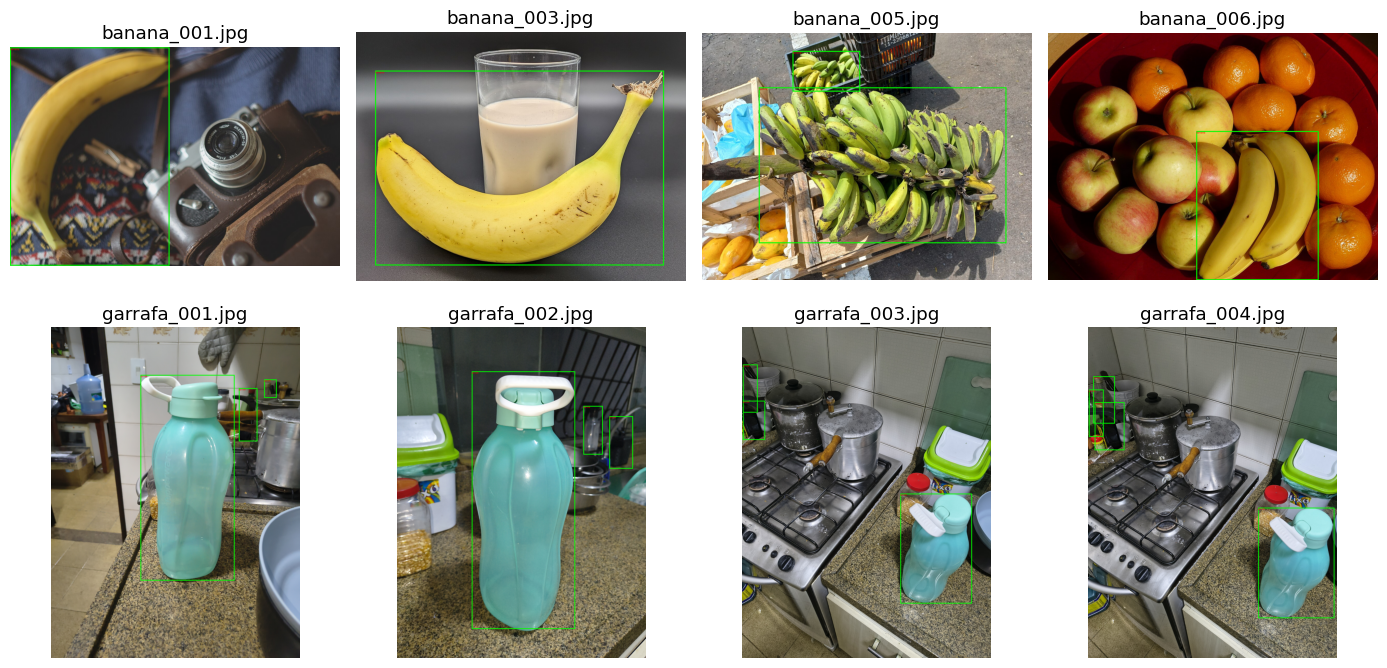

In [4]:
def draw_reference(path):
    image = Image.open(path).convert("RGB")
    draw = ImageDraw.Draw(image)
    labels = DATA / "labels" / Path(path).parent.name / (Path(path).stem + ".txt")
    for line in labels.read_text().splitlines():
        if not line.strip():
            continue
        class_id, x, y, w, h = map(float, line.split())
        corners = [(x-w/2)*image.width, (y-h/2)*image.height,
                   (x+w/2)*image.width, (y+h/2)*image.height]
        draw.rectangle(corners, outline="lime", width=max(2, image.width // 300))
        draw.text((max(0, corners[0]), max(0, corners[1])), CLASSES[int(class_id)], fill="red")
    return image

examples = manifest[manifest.split == "train"].groupby("class_id").head(4)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, (_, row) in zip(axes.flat, examples.iterrows()):
    ax.imshow(draw_reference(row.path)); ax.set_title(row.arquivo); ax.axis("off")
fig.tight_layout(); fig.savefig(OUT / "amostras_rotuladas.png", dpi=160)
plt.show()


## 4. YOLOv5: dois experimentos independentes
Cada execução começa em `yolov5s.pt`; o treino de 60 épocas não continua o de 30.
`patience=0` desativa parada antecipada para preservar os dois orçamentos completos.
O checkpoint `best.pt` é escolhido pelo critério interno de validação do YOLOv5.
Na comparação entre experimentos, usamos mAP@0.5:0.95 de validação, com desempate a favor de 30 épocas.

O agendamento da taxa de aprendizado depende do total de épocas; portanto, comparar 30 e 60
significa comparar dois orçamentos de treinamento, não apenas copiar a trajetória das 30 primeiras épocas.
Os tempos incluem a execução do script, validação interna e gravação de artefatos.


In [5]:
INITIAL_WEIGHTS = WORK / "yolov5s.pt"
if not INITIAL_WEIGHTS.exists():
    urlretrieve("https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt", INITIAL_WEIGHTS)
initial_sha = hashlib.sha256(INITIAL_WEIGHTS.read_bytes()).hexdigest()
training_times = {}
for epochs in EPOCHS:
    start = time.perf_counter()
    run_command([sys.executable, REPO / "train.py", "--data", DATA_YAML,
                 "--weights", INITIAL_WEIGHTS, "--img", IMAGE_SIZE,
                 "--batch-size", BATCH_SIZE, "--epochs", epochs,
                 "--seed", SEED, "--workers", 2, "--device", DEVICE,
                 "--patience", 0, "--project", OUT / "treinos", "--name", f"yolo_{epochs}"], cwd=REPO)
    training_times[epochs] = time.perf_counter() - start
    weights_path = OUT / "treinos" / f"yolo_{epochs}" / "weights" / "best.pt"
    if not weights_path.is_file():
        raise FileNotFoundError("Treino sem best.pt: " + str(weights_path))
    history = pd.read_csv(weights_path.parents[1] / "results.csv")
    if len(history) != epochs:
        raise RuntimeError(f"Treino incompleto: {len(history)} de {epochs} épocas.")
(OUT / "tempos_treino.json").write_text(json.dumps(training_times, indent=2), encoding="utf-8")
(OUT / "pesos_iniciais_sha256.txt").write_text(initial_sha, encoding="utf-8")
display(pd.DataFrame([{"epocas": e, "tempo_treino_s": training_times[e]} for e in EPOCHS]))


,epocas,tempo_treino_s
0,30,191.269535
1,60,300.078378


### Curvas: desempenho e erro
A perda de treino pode continuar caindo enquanto a validação piora: isso sugere sobreajuste.
As perdas de caixa, objeto e classe têm funções diferentes; não comparar seus valores absolutos
com a entropia cruzada da CNN. As curvas são evidência de aprendizado, não prova de generalização.


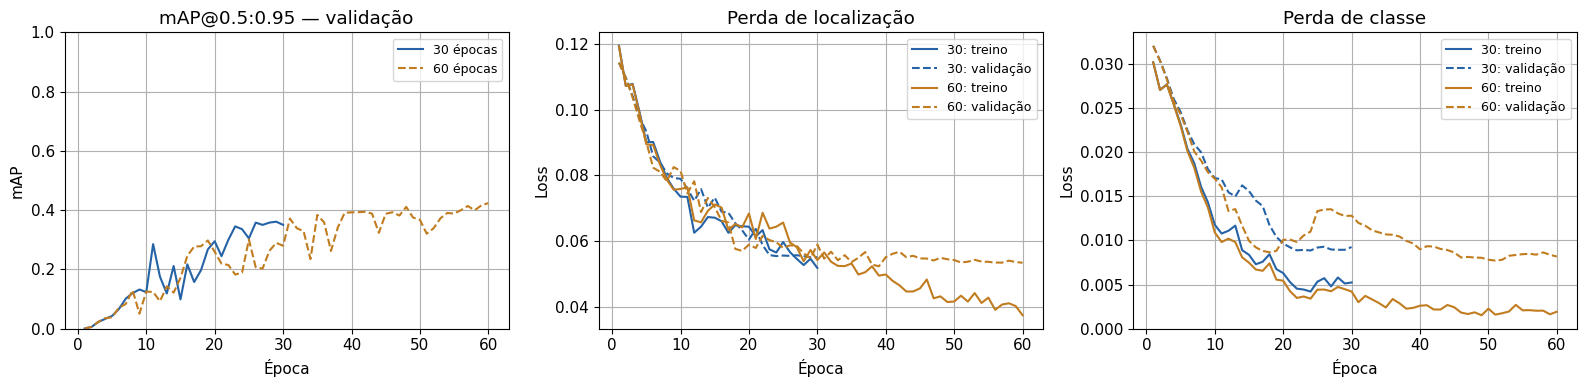

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for epochs in EPOCHS:
    history = pd.read_csv(OUT / "treinos" / f"yolo_{epochs}" / "results.csv")
    history.columns = history.columns.str.strip()
    x = np.arange(1, len(history) + 1)
    color = EPOCH_COLORS[epochs]
    axes[0].plot(x, history["metrics/mAP_0.5:0.95"], color=color,
                 linestyle="-" if epochs == 30 else "--", label=f"{epochs} épocas")
    axes[1].plot(x, history["train/box_loss"], color=color, label=f"{epochs}: treino")
    axes[1].plot(x, history["val/box_loss"], color=color, linestyle="--", label=f"{epochs}: validação")
    axes[2].plot(x, history["train/cls_loss"], color=color, label=f"{epochs}: treino")
    axes[2].plot(x, history["val/cls_loss"], color=color, linestyle="--", label=f"{epochs}: validação")
for ax, title in zip(axes, ["mAP@0.5:0.95 — validação", "Perda de localização", "Perda de classe"]):
    ax.set_title(title); ax.set_xlabel("Época"); ax.legend(fontsize=9)
axes[0].set_ylim(0, 1); axes[0].set_ylabel("mAP")
axes[1].set_ylabel("Loss"); axes[2].set_ylabel("Loss")
fig.tight_layout(); fig.savefig(OUT / "comparacao_epocas.png", dpi=160)
plt.show()


### Validação independente dos checkpoints
Precision mede a proporção de detecções positivas corretas; recall mede a recuperação dos objetos.
mAP resume curvas precisão–recall levando em conta a sobreposição das caixas (IoU).
O limiar baixo de confiança na avaliação preserva candidatos para calcular a curva de AP.
O limiar de demonstração/classificação por imagem permanece fixo em 0,25.


In [7]:
# Importar a implementação oficial a partir da revisão local fixada.
sys.path.insert(0, str(REPO))
from val import run as evaluate_yolov5

detection_records = []
for epochs in EPOCHS:
    metrics, per_class, speeds = evaluate_yolov5(
        data=str(DATA_YAML), weights=str(OUT / "treinos" / f"yolo_{epochs}" / "weights" / "best.pt"),
        task="val", imgsz=IMAGE_SIZE, batch_size=BATCH_SIZE, device=DEVICE,
        workers=2, half=False, conf_thres=0.001, iou_thres=0.6,
        project=str(OUT / "avaliacoes"), name=f"val_{epochs}", plots=True)
    detection_records.append({"split": "val", "epocas": epochs,
        "precision": metrics[0], "recall": metrics[1], "mAP50": metrics[2],
        "mAP50_95": metrics[3], "tempo_treino_s": training_times[epochs]})
validation_table = pd.DataFrame(detection_records)
display(validation_table.round(4))
SELECTED_EPOCHS = int(validation_table.sort_values(["mAP50_95", "epocas"], ascending=[False, True]).iloc[0].epocas)
(OUT / "selecao_validacao.json").write_text(json.dumps({"epocas": SELECTED_EPOCHS,
    "criterio": "maior mAP50_95 de validacao; desempate menor numero de epocas"}), encoding="utf-8")
print("Modelo selecionado pela validação:", SELECTED_EPOCHS, "épocas. Não trocar após observar o teste.")


YOLOv5 🚀 v7.0-551-g2b1bdcd0 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/farmtech_fase6/dataset_20261006T122041599048Z/labels/val.cache... 8 images, 0 backgrounds, 0 corrupt
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% ━━━━━━━━━━━━ 1/1 1.2it/s 0.8s
                   all          8         21      0.732      0.643      0.598      0.362
               garrafa          8         16      0.525      0.485      0.399      0.273
                banana          8          5      0.939        0.8      0.796       0.45
Speed: 0.6ms pre-process, 16.8ms inference, 22.8ms NMS per image at shape (8, 3, 640, 640)
Results saved to /content/farmtech_fase6/resultados/20261006T122041599048Z/avaliacoes/val_30
YOLOv5 🚀 v7.0-551-g2b1bdcd0 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model sum

,split,epocas,precision,recall,mAP50,mAP50_95,tempo_treino_s
0,val,30,0.7320,0.6426,0.5976,0.3618,191.2695
1,val,60,0.8141,0.4875,0.5819,0.4244,300.0784


Modelo selecionado pela validação: 60 épocas. Não trocar após observar o teste.


### Comparação dos orçamentos de treino

Na validação, o treino de 60 épocas obteve mAP@0,5:0,95 de **0,4267**, frente a **0,3861** com 30 épocas: ganho de **4,06 pontos percentuais**. A mAP@0,5 subiu de 0,6190 para 0,6654 e o recall de 0,5689 para 0,6188; a precisão caiu de 0,8658 para 0,8377. Portanto, o ganho em recuperação/localização veio acompanhado de menor precisão nesse conjunto.

O tempo total passou de **202,40 s para 341,11 s**, acréscimo de 138,71 s (68,5%). Pelo critério definido antes do teste — maior mAP@0,5:0,95 de validação — foi selecionado o checkpoint do experimento de **60 épocas**. Essa seleção foi mantida na avaliação final.

São apenas oito imagens de validação e uma seed. O ganho observado não demonstra superioridade estatística nem garante generalização. As curvas de perdas e métricas devem ser interpretadas em conjunto: a melhora da mAP não prova ausência de sobreajuste. As duas execuções partiram dos mesmos pesos pré-treinados; o orçamento maior também altera o agendamento da taxa de aprendizado.


As curvas mostram queda das perdas de localização e classe no treino e na validação. No experimento de 60 épocas, a perda de localização de validação se estabiliza enquanto a de treino continua caindo, ampliando a diferença entre elas. Isso indica retorno decrescente e possível sobreajuste, mas a mAP de validação ainda melhora. Por isso, a conclusão se apoia nas métricas de validação e no teste reservado, sem afirmar que uma perda menor de treino garante melhor resultado fora da amostra.


## 5. CNN treinada do zero
Arquitetura pequena com três blocos convolucionais, pooling, média global, dropout e saída softmax.
Os pesos começam aleatórios. Aumentos aleatórios atuam apenas no treino; a normalização faz parte
do modelo. A seleção do checkpoint usa `val_loss`, sem qualquer acesso ao teste.

A CNN é treinada em CPU para limitar competição de memória com PyTorch neste notebook pequeno.
O custo de treino deve ser interpretado junto com o hardware registrado: não é uma comparação
isolada de velocidade de arquitetura com o YOLO, que pode ter sido treinado em GPU.


In [8]:
import tensorflow as tf
tf.config.set_visible_devices([], "GPU")
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
CNN_SIZE = 128

def load_classification_split(split):
    rows = manifest[manifest.split == split].sort_values("arquivo")
    images = []
    for path in rows.path:
        with Image.open(path) as image:
            images.append(np.asarray(image.convert("RGB").resize((CNN_SIZE, CNN_SIZE)), dtype=np.float32))
    return np.stack(images), rows.class_id.to_numpy(), rows

x_train, y_train, _ = load_classification_split("train")
x_val, y_val, _ = load_classification_split("val")
cnn = tf.keras.Sequential([
    tf.keras.layers.Input((CNN_SIZE, CNN_SIZE, 3)),
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomRotation(0.05, seed=SEED),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3, seed=SEED),
    tf.keras.layers.Dense(2, activation="softmax"),
])
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.summary()
CNN_PATH = OUT / "cnn_do_zero.keras"
start = time.perf_counter()
cnn_history = cnn.fit(x_train, y_train, validation_data=(x_val, y_val),
    epochs=30, batch_size=8, shuffle=True, verbose=2,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
               tf.keras.callbacks.ModelCheckpoint(str(CNN_PATH), monitor="val_loss", save_best_only=True)])
cnn_train_s = time.perf_counter() - start
cnn = tf.keras.models.load_model(CNN_PATH)
cnn_curve = pd.DataFrame(cnn_history.history)
cnn_curve.to_csv(OUT / "cnn_historico.csv", index=False)
(OUT / "cnn_configuracao.json").write_text(json.dumps({"tensorflow": tf.__version__,
    "device": "CPU", "epocas_executadas": len(cnn_curve), "tempo_treino_s": cnn_train_s,
    "epoca_menor_val_loss": int(cnn_curve.val_loss.idxmin() + 1), "parametros": cnn.count_params()}, indent=2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for key, color, label, style in [("", "#2563a6", "Treino", "-"), ("val_", "#c17c1f", "Validação", "--")]:
    axes[0].plot(np.arange(1, len(cnn_curve)+1), cnn_curve[key+"loss"], color=color, linestyle=style, label=label)
    axes[1].plot(np.arange(1, len(cnn_curve)+1), cnn_curve[key+"accuracy"], color=color, linestyle=style, label=label)
for ax, title, ylabel in zip(axes, ["CNN — erro", "CNN — acurácia"], ["Entropia cruzada", "Fração de acertos"]):
    ax.set_title(title); ax.set_xlabel("Época"); ax.set_ylabel(ylabel); ax.legend()
axes[1].set_ylim(0, 1)
fig.tight_layout(); fig.savefig(OUT / "cnn_curvas.png", dpi=160); plt.show()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,714 (92.63 KB)

 Trainable params: 23,714 (92.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
8/8 - 3s - 335ms/step - accuracy: 0.4531 - loss: 0.6914 - val_accuracy: 0.6250 - val_loss: 0.6945
Epoch 2/30
8/8 - 1s - 111ms/step - accuracy: 0.5312 - loss: 0.6754 - val_accuracy: 0.5000 - val_loss: 0.6968
Epoch 3/30
8/8 - 1s - 116ms/step - accuracy: 0.5469 - loss: 0.6495 - val_accuracy: 0.6250 - val_loss: 0.7066
Epoch 4/30
8/8 - 1s - 123ms/step - accuracy: 0.6406 - loss: 0.6200 - val_accuracy: 0.5000 - val_loss: 0.7310
Epoch 5/30
8/8 - 1s - 115ms/step - accuracy: 0.7812 - loss: 0.5681 - val_accuracy: 0.5000 - val_loss: 0.7977
Epoch 6/30
8/8 - 1s - 113ms/step - accuracy: 0.7344 - loss: 0.5416 - val_accuracy: 0.5000 - val_loss: 0.8785
Epoch 7/30
8/8 - 1s - 114ms/step - accuracy: 0.8281 - loss: 0.4609 - val_accuracy: 0.5000 - val_loss: 1.0890


## 6. YOLOv3 padrão e classificação comparável entre abordagens
O YOLOv3 utiliza os pesos originais COCO, sem customização. É a arquitetura do exemplo dos
materiais da disciplina; aqui sua inferência usa OpenCV DNN, evitando compilar Darknet no Colab.
Essa diferença de integração deve ser informada no relatório e no vídeo.

Para a comparação por imagem, o detector escolhe a classe da detecção-alvo de maior confiança
após supressão de caixas sobrepostas; se não houver alvo acima de 0,25, retorna **sem detecção**,
contabilizada como erro. Classes COCO fora das duas classes do estudo são ignoradas.
A CNN escolhe a maior probabilidade softmax e sempre retorna uma classe. Essa assimetria faz
parte do comportamento das soluções e deve ser discutida.

O limiar foi fixado antes do teste; não ajustá-lo para melhorar o resultado nas 8 imagens reservadas.


**Ajuste operacional observado:** o endereço antigo dos pesos retornou HTTP 403. O download foi corrigido para `https://data.pjreddie.com/files/yolov3.weights`, indicado pelo projeto oficial, com cabeçalho `User-Agent`, arquivo temporário e substituição apenas após concluir a transferência. A origem e o SHA-256 dos arquivos efetivamente usados estão em `yolov3_fontes_e_hashes.json`.


In [9]:
import cv2
cv2.setNumThreads(1)
torch.set_num_threads(1)
YOLO3 = WORK / "yolov3"
YOLO3.mkdir(exist_ok=True)
downloads = {
    "yolov3.cfg": "https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg",
    "coco.names": "https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names",
    "yolov3.weights": "https://data.pjreddie.com/files/yolov3.weights",
}
for filename, url in downloads.items():
    target = YOLO3 / filename
    if not target.exists():
        print("Baixando:", filename, url, flush=True)
        from urllib.request import Request, urlopen
        request = Request(url, headers={"User-Agent": "Mozilla/5.0"})
        temporary = target.with_suffix(target.suffix + ".part")
        with urlopen(request, timeout=90) as response, temporary.open("wb") as output:
            shutil.copyfileobj(response, output)
        temporary.replace(target)
coco_labels = (YOLO3 / "coco.names").read_text().splitlines()
if any(name not in coco_labels for name in COCO_NAMES):
    raise ValueError("Classe-alvo ausente do YOLOv3 COCO; revisar a escolha dos objetos.")
coco_to_local = {coco_labels.index(name): i for i, name in enumerate(COCO_NAMES)}
network = cv2.dnn.readNetFromDarknet(str(YOLO3 / "yolov3.cfg"), str(YOLO3 / "yolov3.weights"))
network.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
network.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)
standard = cv2.dnn_DetectionModel(network)
standard.setInputParams(scale=1/255, size=(416, 416), swapRB=True, crop=False)

def predict_yolov3(rgb):
    ids, scores, boxes = standard.detect(cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR),
                                         confThreshold=CONFIDENCE, nmsThreshold=NMS_IOU)
    detections = []
    for class_id, score, box in zip(np.asarray(ids).reshape(-1), np.asarray(scores).reshape(-1), boxes):
        if int(class_id) in coco_to_local:
            x, y, w, h = map(float, box)
            detections.append([x, y, x+w, y+h, float(score), coco_to_local[int(class_id)]])
    if not detections:
        return -1, 0.0, []
    best = max(detections, key=lambda row: row[4])
    return int(best[5]), float(best[4]), detections

# Os dois checkpoints ficam em CPU para a comparação de inferência no mesmo hardware.
yolo_models = {}
for epochs in EPOCHS:
    weights_path = OUT / "treinos" / f"yolo_{epochs}" / "weights" / "best.pt"
    model = torch.hub.load(str(REPO), "custom", path=str(weights_path), source="local", device="cpu")
    model.conf, model.iou = CONFIDENCE, NMS_IOU
    model.eval()
    yolo_models[epochs] = model

def make_yolo_predictor(model):
    def predict(rgb):
        with torch.inference_mode():
            rows = model(rgb, size=IMAGE_SIZE).xyxy[0].cpu().numpy().tolist()
        if not rows:
            return -1, 0.0, []
        best = max(rows, key=lambda row: row[4])
        return int(best[5]), float(best[4]), rows
    return predict

def predict_cnn(rgb):
    resized = np.asarray(Image.fromarray(rgb).resize((CNN_SIZE, CNN_SIZE)), dtype=np.float32)
    probabilities = cnn(resized[None, ...], training=False).numpy()[0]
    return int(np.argmax(probabilities)), float(np.max(probabilities)), []

predictors = {f"YOLOv5_{e}": make_yolo_predictor(yolo_models[e]) for e in EPOCHS}
predictors.update({"YOLOv3_padrao": predict_yolov3, "CNN_do_zero": predict_cnn})
asset_hashes = {filename: hashlib.sha256((YOLO3 / filename).read_bytes()).hexdigest() for filename in downloads}
(OUT / "yolov3_fontes_e_hashes.json").write_text(json.dumps({"urls": downloads, "sha256": asset_hashes}, indent=2))


Baixando: yolov3.cfg https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
Baixando: coco.names https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names
Baixando: yolov3.weights https://data.pjreddie.com/files/yolov3.weights
YOLOv5 🚀 v7.0-551-g2b1bdcd0 Python-3.13.15 torch-2.11.0+cu130 CPU

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 
YOLOv5 🚀 v7.0-551-g2b1bdcd0 Python-3.13.15 torch-2.11.0+cu130 CPU

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


559

### Comparação por imagem na validação
Usar as mesmas imagens e a mesma convenção de classe. F1 macro atribui o mesmo peso às duas
classes. A ausência de detecção reduz recall e acurácia; não excluir esses casos da tabela.


O F1 macro é a média somente das duas classes-alvo (`garrafa` e `banana`); a ausência de detecção gera falso negativo para a classe real, sem receber uma terceira parcela na média. Portanto, F1 macro e acurácia não são intercambiáveis: por exemplo, um detector sem confusões entre classes ainda perde acurácia e recall quando se abstém.


In [10]:
prediction_rows, cached_predictions = [], {}

def evaluate_classification(split):
    for name, predictor in predictors.items():
        for row in manifest[manifest.split == split].sort_values("arquivo").itertuples():
            with Image.open(row.path) as image:
                rgb = np.asarray(image.convert("RGB"))
            predicted, score, boxes = predictor(rgb)
            prediction_rows.append({"modelo": name, "split": split, "arquivo": row.arquivo,
                                    "real": row.class_id, "previsto": predicted, "score": score})
            cached_predictions[(name, split, row.arquivo)] = boxes

def classification_summary(frame):
    records = []
    for (name, split), part in frame.groupby(["modelo", "split"]):
        precision, recall, f1, _ = precision_recall_fscore_support(
            part.real, part.previsto, labels=[0, 1], average="macro", zero_division=0)
        records.append({"modelo": name, "split": split, "n": len(part),
            "acertos": int((part.real == part.previsto).sum()),
            "sem_deteccao": int((part.previsto == -1).sum()),
            "acuracia": accuracy_score(part.real, part.previsto),
            "precision_macro": precision, "recall_macro": recall, "F1_macro": f1})
    return pd.DataFrame(records)

evaluate_classification("val")
display(classification_summary(pd.DataFrame(prediction_rows)).round(4))


,modelo,split,n,acertos,sem_deteccao,acuracia,precision_macro,recall_macro,F1_macro
0,CNN_do_zero,val,8,5,0,0.625,0.7857,0.625,0.5636
1,YOLOv3_padrao,val,8,6,2,0.750,1.0000,0.750,0.8571
2,YOLOv5_30,val,8,8,0,1.000,1.0000,1.000,1.0000
3,YOLOv5_60,val,8,7,0,0.875,0.9000,0.875,0.8730


## 7. Avaliação final no teste reservado
O protocolo, os hiperparâmetros e o YOLOv5 selecionado já foram definidos antes desta etapa.
Relatamos os dois orçamentos no teste porque a atividade pede a comparação, mas não usamos
esses resultados para trocar a seleção, repetir ajustes ou escolher o melhor limiar.

Com 8 imagens de teste, um acerto equivale a **12,5 pontos percentuais** de acurácia.
Repetir inferências para medir tempo não aumenta o número de imagens independentes.
O conjunto é pequeno demais para alegações de desempenho em produção.


In [11]:
for epochs in EPOCHS:
    metrics, per_class, speeds = evaluate_yolov5(
        data=str(DATA_YAML), weights=str(OUT / "treinos" / f"yolo_{epochs}" / "weights" / "best.pt"),
        task="test", imgsz=IMAGE_SIZE, batch_size=BATCH_SIZE, device=DEVICE,
        workers=2, half=False, conf_thres=0.001, iou_thres=0.6,
        project=str(OUT / "avaliacoes"), name=f"test_{epochs}", plots=True)
    detection_records.append({"split": "test", "epocas": epochs,
        "precision": metrics[0], "recall": metrics[1], "mAP50": metrics[2],
        "mAP50_95": metrics[3], "tempo_treino_s": training_times[epochs]})
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
detection_table = pd.DataFrame(detection_records)
detection_table.to_csv(OUT / "metricas_deteccao.csv", index=False)
display(detection_table.round(4))

evaluate_classification("test")
predictions = pd.DataFrame(prediction_rows)
summary = classification_summary(predictions)
predictions.to_csv(OUT / "predicoes_por_imagem.csv", index=False)
summary.to_csv(OUT / "comparacao_classificacao.csv", index=False)
display(summary.round(4))


YOLOv5 🚀 v7.0-551-g2b1bdcd0 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /content/farmtech_fase6/dataset_20261006T122041599048Z/labels/test... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 566.1it/s 0.0s
test: New cache created: /content/farmtech_fase6/dataset_20261006T122041599048Z/labels/test.cache
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% ━━━━━━━━━━━━ 1/1 1.9it/s 0.5s
                   all          8         12      0.823      0.812      0.873      0.594
               garrafa          8          8      0.758      0.875      0.875      0.624
                banana          8          4      0.887       0.75       0.87      0.564
Speed: 0.5ms pre-process, 12.4ms inference, 3.5ms NMS per image at shape (8, 3, 640, 640)
Results saved to /content/farmtech_fase6/resultados/20261006T122041599048Z/avali

,split,epocas,precision,recall,mAP50,mAP50_95,tempo_treino_s
0,val,30,0.7320,0.6426,0.5976,0.3618,191.2695
1,val,60,0.8141,0.4875,0.5819,0.4244,300.0784
2,test,30,0.8226,0.8125,0.8726,0.5944,191.2695
3,test,60,0.9329,0.5625,0.7989,0.5556,300.0784


,modelo,split,n,acertos,sem_deteccao,acuracia,precision_macro,recall_macro,F1_macro
0,CNN_do_zero,test,8,5,0,0.625,0.7857,0.625,0.5636
1,CNN_do_zero,val,8,5,0,0.625,0.7857,0.625,0.5636
2,YOLOv3_padrao,test,8,7,1,0.875,1.0000,0.875,0.9286
3,YOLOv3_padrao,val,8,6,2,0.750,1.0000,0.750,0.8571
4,YOLOv5_30,test,8,6,2,0.750,1.0000,0.750,0.8571
5,YOLOv5_30,val,8,8,0,1.000,1.0000,1.000,1.0000
6,YOLOv5_60,test,8,5,3,0.625,1.0000,0.625,0.7619
7,YOLOv5_60,val,8,7,0,0.875,0.9000,0.875,0.8730


### Erros por classe
A matriz contém duas linhas reais e três colunas previstas: as duas classes e ausência de detecção.
Para a CNN, a última coluna será zero por definição. O gráfico mantém escalas iguais entre modelos.


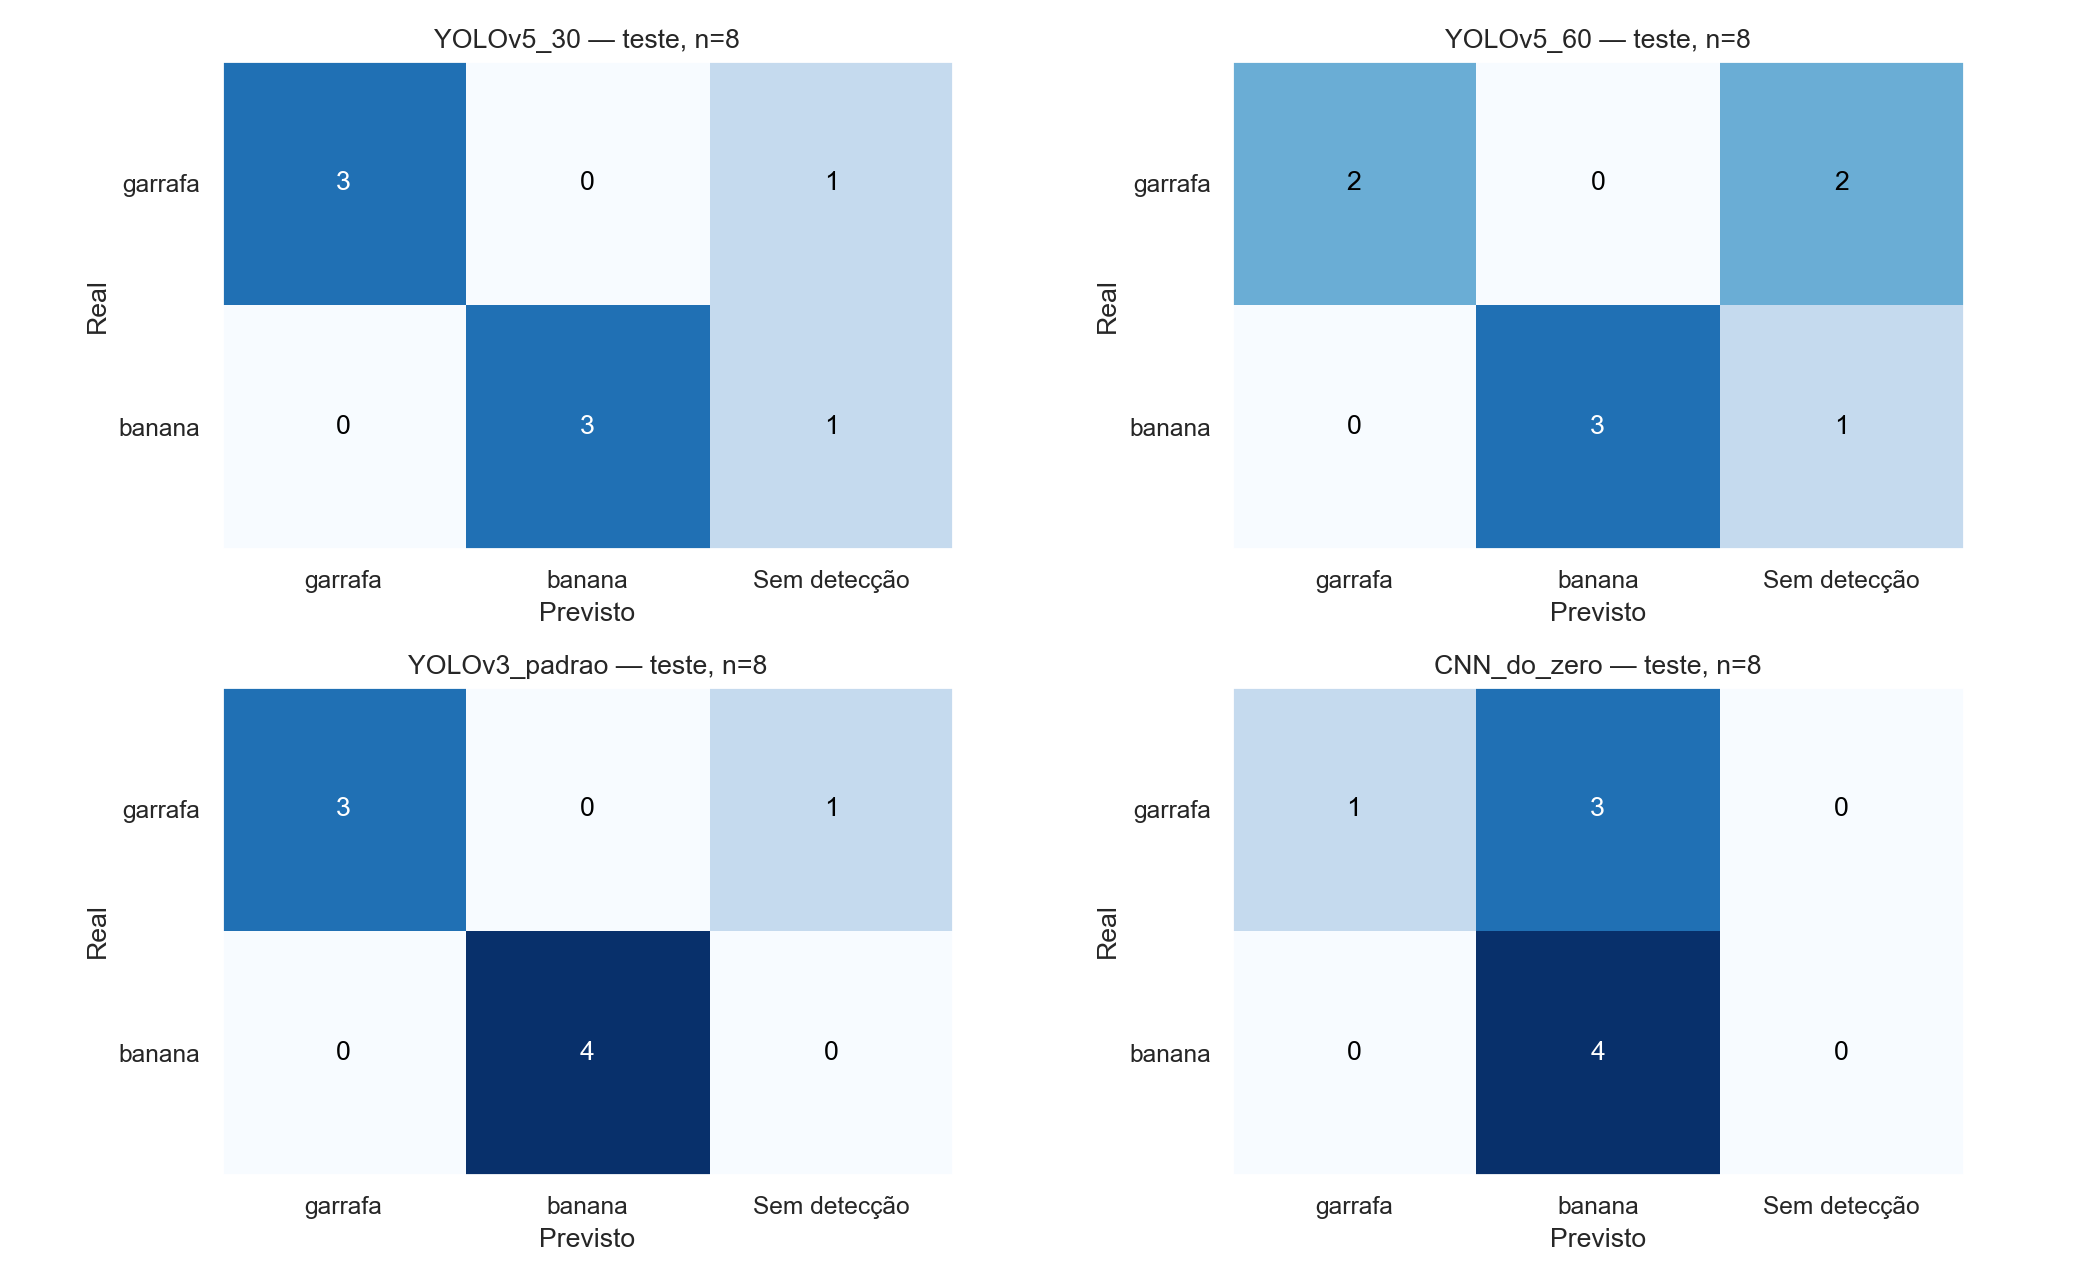

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, name in zip(axes.flat, predictors):
    part = predictions[(predictions.modelo == name) & (predictions.split == "test")]
    matrix = confusion_matrix(part.real, part.previsto, labels=[0, 1, -1])[:2, :]
    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=4)
    ax.set_xticks(range(3), CLASSES + ["Sem detecção"])
    ax.set_yticks(range(2), CLASSES)
    ax.set_xlabel("Previsto"); ax.set_ylabel("Real"); ax.set_title(name + " — teste, n=8")
    ax.grid(False)
    for (r, c), count in np.ndenumerate(matrix):
        ax.text(c, r, str(count), ha="center", va="center", color="white" if count > 2 else "black")
fig.tight_layout(); fig.savefig(OUT / "matrizes_confusao_teste.png", dpi=160); plt.show()


### Evidências visuais: todas as imagens de teste
Exibir as 8 imagens, inclusive falhas. As caixas são previsões; o título informa a classe real
e a classe atribuída. A confiança de uma caixa não é a acurácia do modelo.
As imagens individuais exportadas podem ser usadas como prints na entrega e na demonstração.


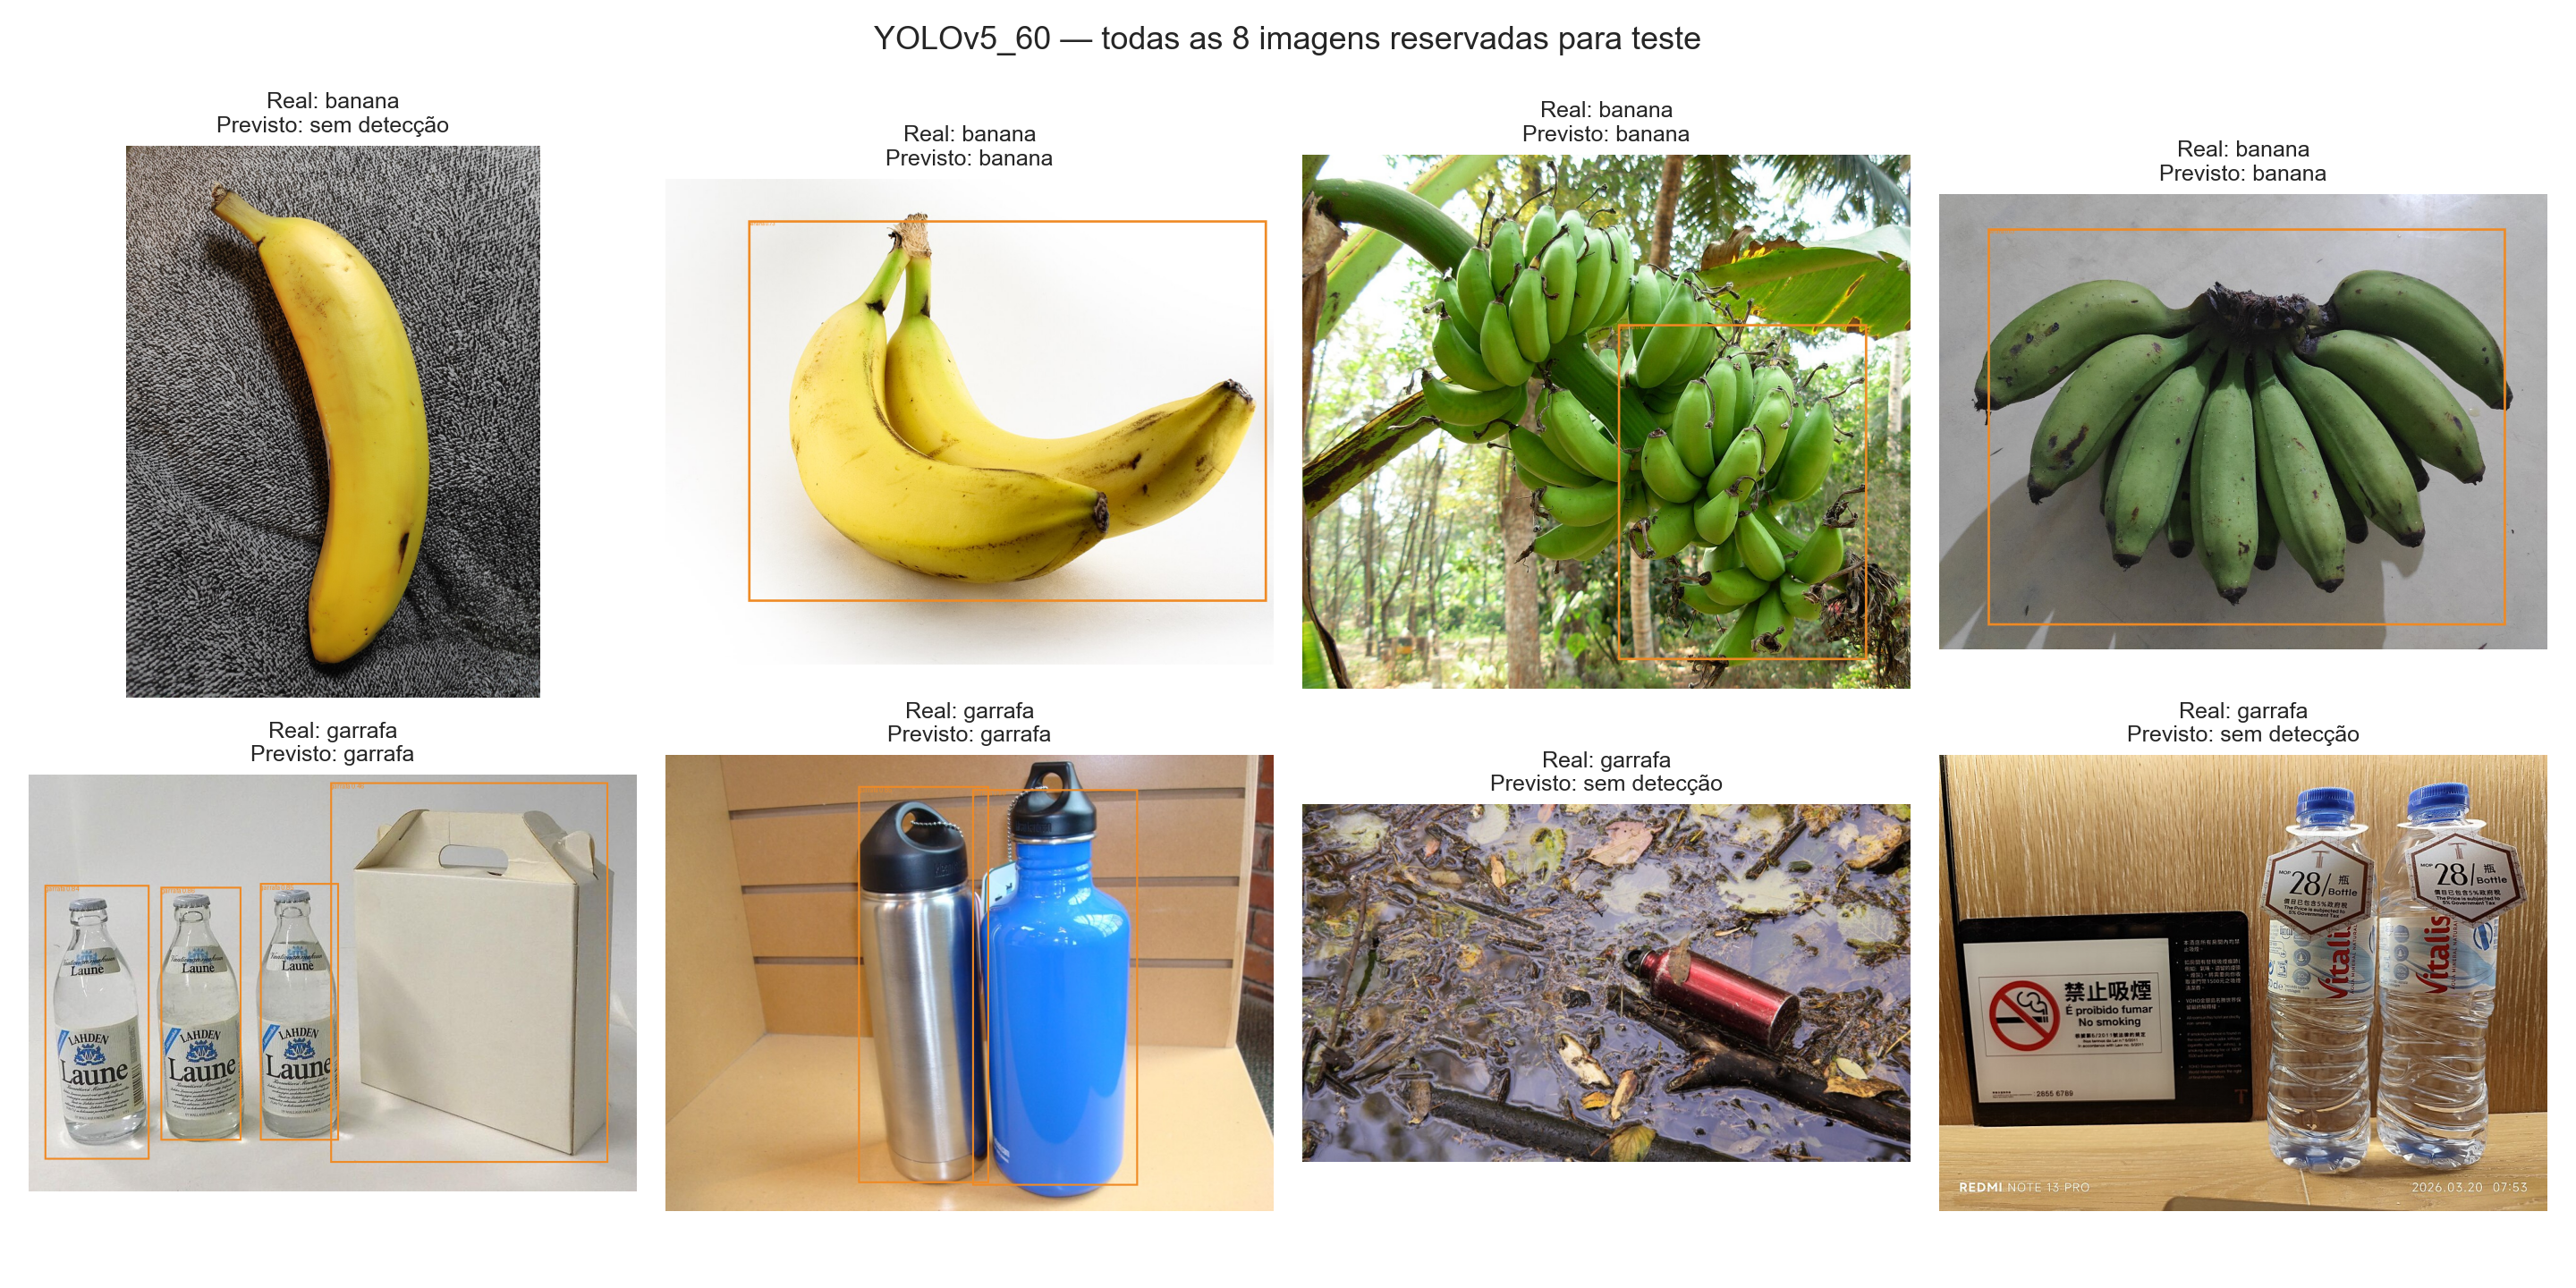

In [13]:
selected_name = f"YOLOv5_{SELECTED_EPOCHS}"
EVIDENCE = OUT / "imagens_teste"
EVIDENCE.mkdir(exist_ok=True)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, row in zip(axes.flat, manifest[manifest.split == "test"].sort_values("arquivo").itertuples()):
    image = Image.open(row.path).convert("RGB")
    draw = ImageDraw.Draw(image)
    for x1, y1, x2, y2, score, class_id in cached_predictions[(selected_name, "test", row.arquivo)]:
        draw.rectangle([x1, y1, x2, y2], outline="#ef8a24", width=max(2, image.width // 250))
        draw.text((max(0, x1), max(0, y1)), f"{CLASSES[int(class_id)]} {score:.2f}", fill="#ef8a24")
    result = predictions[(predictions.modelo == selected_name) & (predictions.split == "test") & (predictions.arquivo == row.arquivo)].iloc[0]
    label = CLASSES[int(result.previsto)] if result.previsto >= 0 else "sem detecção"
    image.save(EVIDENCE / (Path(row.arquivo).stem + "_predicao.jpg"))
    ax.imshow(image); ax.set_title(f"Real: {row.classe}\nPrevisto: {label}", fontsize=10); ax.axis("off")
fig.suptitle(selected_name + " — todas as 8 imagens reservadas para teste")
fig.tight_layout(); fig.savefig(OUT / "painel_teste.png", dpi=180); plt.show()


## 8. Tempo de inferência no mesmo ambiente
Comparação em CPU, uma thread por biblioteca, lote de uma imagem, três aquecimentos e cinco
repetições por imagem. O intervalo medido inclui preparação da imagem, rede e pós-processamento;
exclui leitura de arquivo, carregamento do modelo e gravação de prints.
YOLOv5 usa entrada-alvo 640, YOLOv3 usa 416 e CNN usa 128 pixels. Assim, medimos estas configurações
de solução; não isolamos o efeito da arquitetura. Reportar mediana e percentil 95, sem prometer
os mesmos tempos em outro computador. O treino do YOLOv3 é não aplicável neste projeto.


In [14]:
test_images = []
for path in manifest[manifest.split == "test"].sort_values("arquivo").path:
    with Image.open(path) as image:
        test_images.append(np.asarray(image.convert("RGB")))
timing_records = []
for name, predictor in predictors.items():
    for _ in range(3):
        predictor(test_images[0])
    for repetition in range(5):
        for i, rgb in enumerate(test_images):
            start = time.perf_counter()
            predictor(rgb)
            elapsed_ms = (time.perf_counter() - start) * 1000
            timing_records.append({"modelo": name, "repeticao": repetition, "imagem": i, "tempo_ms": elapsed_ms})
timings = pd.DataFrame(timing_records)
timings.to_csv(OUT / "tempos_inferencia_brutos.csv", index=False)
latencies = timings.groupby("modelo").tempo_ms.agg(
    mediana_ms="median", p95_ms=lambda s: s.quantile(0.95)).reset_index()
comparison = summary[summary.split == "test"].merge(latencies, on="modelo")
costs = {f"YOLOv5_{e}": training_times[e] for e in EPOCHS}
costs.update({"CNN_do_zero": cnn_train_s, "YOLOv3_padrao": np.nan})
comparison["tempo_treino_s"] = comparison.modelo.map(costs)
comparison.to_csv(OUT / "comparacao_final.csv", index=False)
display(comparison.round(4))
print("NaN em tempo de treino do YOLOv3 = não aplicável; o pré-treino externo não foi medido.")


,modelo,split,n,acertos,sem_deteccao,...,recall_macro,F1_macro,mediana_ms,p95_ms,tempo_treino_s
0,CNN_do_zero,test,8,5,0,...,0.625,0.5636,36.0977,55.9411,8.2949
1,YOLOv3_padrao,test,8,7,1,...,0.875,0.9286,994.6750,1195.0307,NaN
2,YOLOv5_30,test,8,6,2,...,0.750,0.8571,161.7674,192.4769,191.2695
3,YOLOv5_60,test,8,5,3,...,0.625,0.7619,170.5445,241.7180,300.0784


NaN em tempo de treino do YOLOv3 = não aplicável; o pré-treino externo não foi medido.


## 9. Resultado da verificação em sessão limpa — 06/10/2026

As 15 células foram executadas em uma sessão T4 nova, na ordem 1–15, sem erro e sem ajustes intermediários no código. O dataset foi obtido pelo link público do GitHub, com `USE_DRIVE=False`. Apenas as duas configurações documentadas de acesso aos dados diferem da execução de 04/10; splits, seed e hiperparâmetros permanecem iguais.

Os históricos contêm 30 e 60 épocas completas. Os tempos foram 191,27 s e 300,08 s. O checkpoint de 60 épocas voltou a ser selecionado pela validação: mAP@0,5:0,95 de 0,4244, contra 0,3618 em 30 épocas. No teste, os valores foram 0,5556 e 0,5944, respectivamente; a seleção pela validação foi mantida.

| Modelo | Acertos no teste | Sem detecção | Mediana CPU (ms) |
|---|---:|---:|---:|
| CNN_do_zero | 5/8 | 0 | 36.10 |
| YOLOv3_padrao | 7/8 | 1 | 994.67 |
| YOLOv5_30 | 6/8 | 2 | 161.77 |
| YOLOv5_60 | 5/8 | 3 | 170.54 |


A CNN novamente parou em 7 épocas e restaurou a época 1, com perda de validação mínima de 0,6945. As curvas mostram a perda de treino caindo e a de validação subindo, evidência de sobreajuste. A CNN e o YOLOv3 mantiveram os acertos da primeira execução; os dois YOLOv5 variaram em uma imagem de teste cada: 30 épocas passou de 5/8 para 6/8, e 60 épocas passou de 6/8 para 5/8. A ausência de detecção conta como erro; acurácia por imagem não substitui mAP de localização.

O painel mostra todas as oito imagens. O YOLOv5 selecionado não detectou a banana solta sobre tecido nem duas cenas de garrafas. Em outra cena, também incluiu uma caixa de papelão entre as detecções. Esses exemplos mostram por que acertar a classe predominante não garante contar ou localizar corretamente todos os objetos.

O código é reproduzível operacionalmente, mas os treinos YOLOv5 não produziram métricas idênticas entre as duas sessões, mesmo com seed fixa e a mesma GPU declarada. A causa exata dessa variação não foi isolada. Duas execuções e oito imagens de teste são insuficientes para caracterizar estabilidade ou desempenho de produção. As medições de tempo dependem da sessão; não representam uma mudança de arquitetura.

Esta rodada verifica a execução do projeto e não substitui a análise nem os pesos publicados da rodada original. O relatório principal continua vinculado à execução de 04/10/2026; este caderno conserva exclusivamente as saídas de `20261006T122041599048Z`.

## 10. Preservação e entrega

O ZIP `RESULTADOS-FARMTECH-20261006T122041599048Z.zip` contém todos os artefatos calculados nesta sessão. Ele foi baixado para a pasta local `Graduação/Fase 6/Atividade` e sua integridade foi conferida. As 67 imagens de resultados foram decodificadas, os dois históricos têm o número completo de épocas e as métricas de classificação foram recalculadas contra as previsões individuais.

As saídas originais e o código foram preservados. Os gráficos de matriz de confusão e painel das oito imagens, ausentes na exportação original do Colab, foram reincorporados a partir dos PNGs desta mesma execução, sem modificação dos pixels. O texto foi atualizado para descrever esta rodada.

Vídeo demonstrativo, link no README e envio pelo portal continuam pendentes. O [projeto principal](https://github.com/teteuriscado-bot/MatheusSilvaRiscado) preserva os resultados da primeira rodada; não misturar os números das duas execuções na apresentação.

In [15]:
expected_outputs = ["manifesto_auditado.csv", "comparacao_epocas.png", "cnn_curvas.png",
    "metricas_deteccao.csv", "comparacao_classificacao.csv", "predicoes_por_imagem.csv",
    "comparacao_final.csv", "matrizes_confusao_teste.png", "painel_teste.png",
    "ambiente.json", "requirements-executados.txt"]
missing = [name for name in expected_outputs if not (OUT / name).is_file()]
if missing:
    raise FileNotFoundError("Resultados faltantes: " + ", ".join(missing))
print("Artefatos calculados em:", OUT)
print("Revisar as conclusões e salvar o notebook COM AS SAÍDAS antes de publicar.")

# Preservar uma cópia portátil dos resultados, além da pasta no Drive.
archive = shutil.make_archive(str(WORK / ("RESULTADOS-FARMTECH-" + RUN_ID)), "zip", OUT)
print("Arquivo de resultados:", archive)
from google.colab import files
files.download(archive)


Artefatos calculados em: /content/farmtech_fase6/resultados/20261006T122041599048Z
Revisar as conclusões e salvar o notebook COM AS SAÍDAS antes de publicar.
Arquivo de resultados: /content/farmtech_fase6/RESULTADOS-FARMTECH-20261006T122041599048Z.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>